In [1]:
%pip install h5py matplotlib numpy scipy scikit-image tifffile

   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 3.2/3.2 MB 37.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



C:\Users\ryanc\Downloads\PCA_FINO2\250nMFINO2,6h\Ilastik\1_0028.h5
  file size: 0.076 MiB
  dataset: /exported_data
  shape: (143, 123, 2) = height 143 x width 123 x 2 classes
  axes: ('y', 'x', 'c')
  dtype: uint16; uncompressed array size: 0.067 MiB
  class 0: probability range 0.000 to 1.000
  class 1: probability range 0.000 to 1.000
  class-probability sum: 0.999985 to 1.000000 (should be about 1)


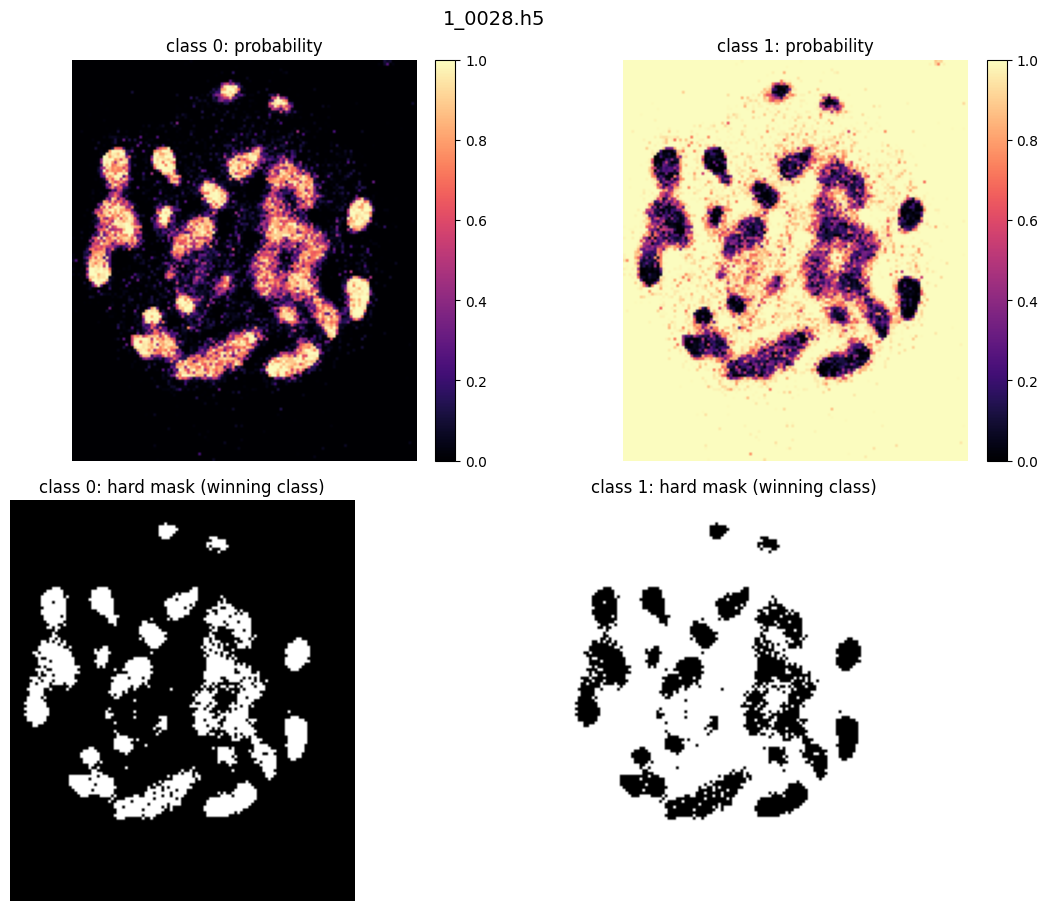

In [2]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

# --------------------------- EDIT ONLY THIS SECTION ---------------------------
FILE_PATHS = [
    r"Ilastik\1_0028.h5",
    # r"C:\path\to\another_file.h5",
]
CLASS_NAMES = ["class 0", "class 1"]  # Rename using your Ilastik label order.
# -----------------------------------------------------------------------------

DATASET = "exported_data"

for file_path in map(Path, FILE_PATHS):
    if not file_path.is_file():
        raise FileNotFoundError(f"File not found: {file_path.resolve()}")

    with h5py.File(file_path, "r") as h5_file:
        dataset = h5_file[DATASET]
        shape, dtype = dataset.shape, dataset.dtype
        axes = dataset.attrs.get("DIMENSION_LABELS", [])
        axes = tuple(a.decode() if isinstance(a, bytes) else str(a) for a in axes)
        data = dataset[...]

    # These Ilastik files are expected to be 2D spatial data plus 2 classes: (y, x, c).
    if len(shape) != 3 or shape[-1] != 2:
        raise ValueError(
            f"Expected (height, width, 2 classes), but {file_path.name} has {shape}."
        )

    scale = np.iinfo(dtype).max if np.issubdtype(dtype, np.integer) else 1.0
    probabilities = data.astype(np.float32) / scale
    hard_labels = probabilities.argmax(axis=-1)

    disk_mib = file_path.stat().st_size / 1024**2
    memory_mib = data.nbytes / 1024**2
    print(f"\n{file_path.resolve()}")
    print(f"  file size: {disk_mib:.3f} MiB")
    print(f"  dataset: /{DATASET}")
    print(f"  shape: {shape} = height {shape[0]} x width {shape[1]} x {shape[2]} classes")
    print(f"  axes: {axes or 'not recorded'}")
    print(f"  dtype: {dtype}; uncompressed array size: {memory_mib:.3f} MiB")
    for channel, name in enumerate(CLASS_NAMES):
        values = probabilities[..., channel]
        print(f"  {name}: probability range {values.min():.3f} to {values.max():.3f}")
    probability_sum = probabilities.sum(axis=-1)
    print(
        f"  class-probability sum: {probability_sum.min():.6f} to "
        f"{probability_sum.max():.6f} (should be about 1)"
    )

    fig, axes_plot = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
    for channel, name in enumerate(CLASS_NAMES):
        probability_ax = axes_plot[0, channel]
        image = probability_ax.imshow(
            probabilities[..., channel], cmap="magma", vmin=0, vmax=1
        )
        probability_ax.set_title(f"{name}: probability")
        probability_ax.axis("off")
        fig.colorbar(image, ax=probability_ax, fraction=0.046, pad=0.04)

        mask_ax = axes_plot[1, channel]
        mask_ax.imshow(hard_labels == channel, cmap="gray", vmin=0, vmax=1)
        mask_ax.set_title(f"{name}: hard mask (winning class)")
        mask_ax.axis("off")

    fig.suptitle(file_path.name, fontsize=14)
    plt.show()


1_IMG0028_250nM_100_(-)FINO2_PKMO_PKMO.Confocal.ome.tif: 13 connected regions -> 33 objects; probability >= 0.50, pre-watershed size >= 40 pixels, watershed=True


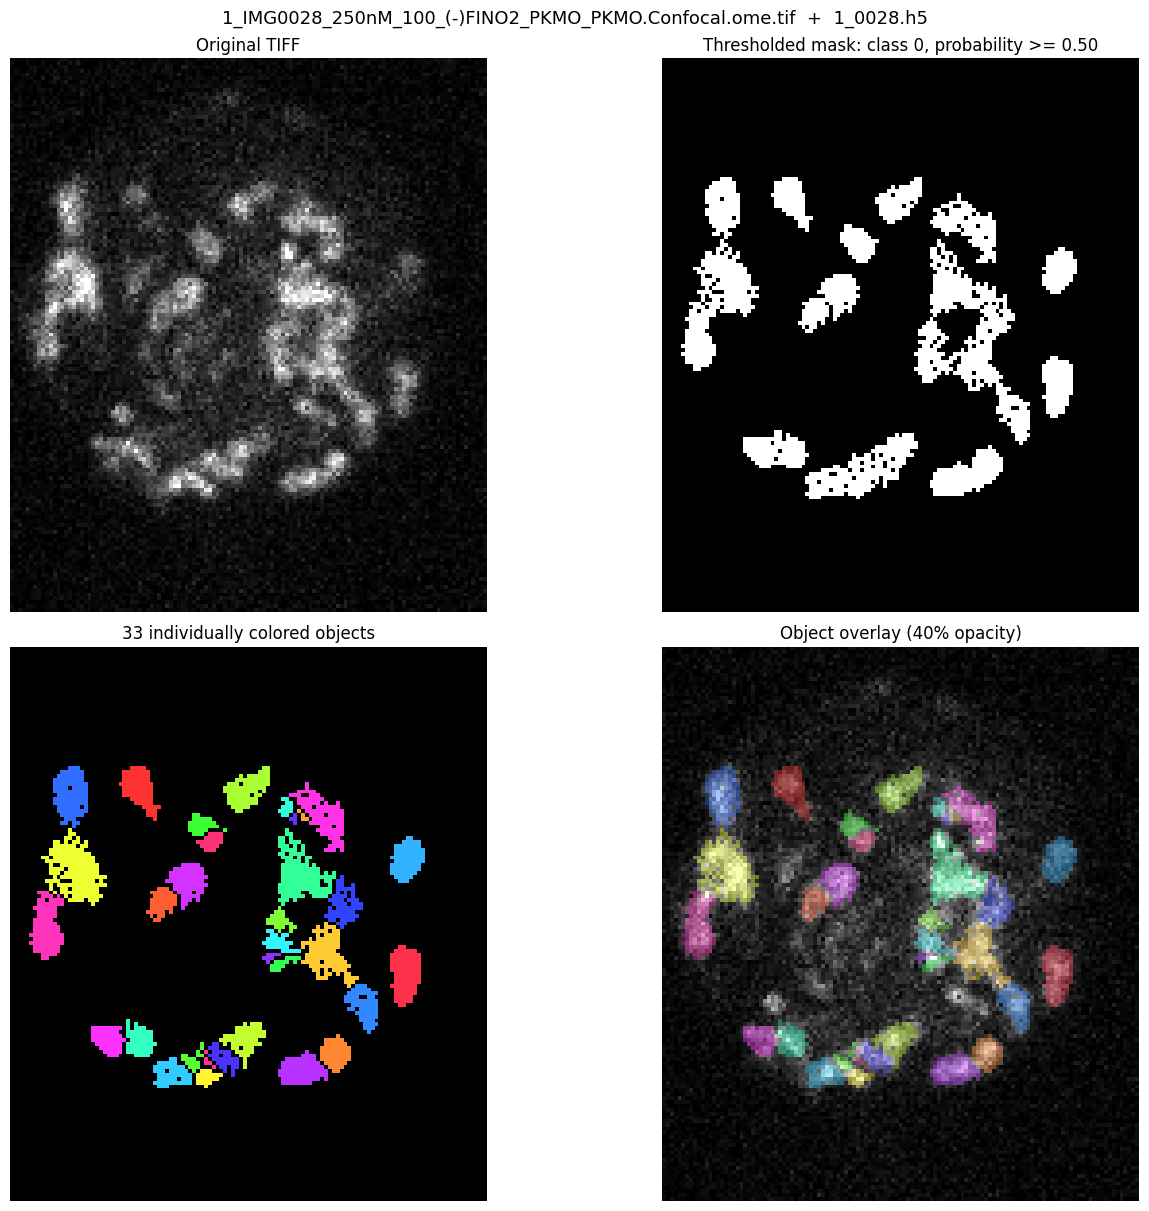

In [10]:
# TIFF viewer with optional Ilastik mask overlay
from pathlib import Path
import re

import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import numpy as np
from scipy import ndimage
from skimage.morphology import h_maxima
from skimage.segmentation import watershed
import tifffile

# --------------------------- EDIT ONLY THIS SECTION ---------------------------
TIF_PATHS = [
    r"1_IMG0028_250nM_100_(-)FINO2_PKMO_PKMO.Confocal.ome.tif",
    # r"2_IMG0027_250nM_100_(-)FINO2_PKMO_PKMO.Confocal.ome.tif",
]
MASK_FOLDER = Path("Ilastik")
MASK_CLASS = 0       # Change to 1 to inspect the other Ilastik class.
PROBABILITY_THRESHOLD = 0.50  # Keep pixels at or above this probability (0 to 1).
MIN_OBJECT_PIXELS = 40         # Increase this to hide tiny isolated specks.
APPLY_WATERSHED = True        # Gently split connected regions at narrow points.
WATERSHED_H = 1.0             # Higher = fewer splits; lower = more aggressive.
SHOW_OVERLAY = True  # False displays only the original TIFF.
OVERLAY_ALPHA = 0.40 # 0 = invisible mask; 1 = opaque mask.
# -----------------------------------------------------------------------------

for tif_path in map(Path, TIF_PATHS):
    if not tif_path.is_file():
        raise FileNotFoundError(f"TIFF not found: {tif_path.resolve()}")

    match = re.match(r"^(\d+)_IMG(\d+)", tif_path.name, flags=re.IGNORECASE)
    if match is None:
        raise ValueError(
            f"Cannot pair {tif_path.name}: expected a name beginning like 1_IMG0028."
        )
    sample_number, image_number = match.groups()
    h5_path = MASK_FOLDER / f"{sample_number}_{image_number}.h5"

    image = tifffile.imread(tif_path)
    if image.ndim != 2:
        raise ValueError(f"Expected one 2D TIFF plane; {tif_path.name} has shape {image.shape}.")

    # Percentile contrast makes dim fluorescence easier to see without changing the data.
    vmin, vmax = np.percentile(image, [1, 99.8])
    if vmax <= vmin:
        vmin, vmax = image.min(), image.max()

    if not SHOW_OVERLAY:
        fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
        ax.imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
        ax.set_title(f"Original TIFF\n{tif_path.name}")
        ax.axis("off")
        plt.show()
        continue

    if not h5_path.is_file():
        raise FileNotFoundError(f"Matching mask not found: {h5_path.resolve()}")
    with h5py.File(h5_path, "r") as h5_file:
        probability_data = h5_file["exported_data"][...]

    if probability_data.shape[:2] != image.shape:
        raise ValueError(
            f"Size mismatch: TIFF {image.shape}, mask {probability_data.shape[:2]}."
        )
    if MASK_CLASS not in range(probability_data.shape[-1]):
        raise ValueError(f"MASK_CLASS must be 0 to {probability_data.shape[-1] - 1}.")
    if not 0 <= PROBABILITY_THRESHOLD <= 1:
        raise ValueError("PROBABILITY_THRESHOLD must be between 0 and 1.")
    if MIN_OBJECT_PIXELS < 1:
        raise ValueError("MIN_OBJECT_PIXELS must be at least 1.")
    if WATERSHED_H <= 0:
        raise ValueError("WATERSHED_H must be greater than 0.")

    scale = (
        np.iinfo(probability_data.dtype).max
        if np.issubdtype(probability_data.dtype, np.integer)
        else 1.0
    )
    class_probability = probability_data[..., MASK_CLASS].astype(np.float32) / scale
    hard_mask = class_probability >= PROBABILITY_THRESHOLD

    # Four-neighbor connectivity: corner contact alone does not join two objects.
    connectivity = ndimage.generate_binary_structure(2, 1)
    initial_labels, _ = ndimage.label(hard_mask, structure=connectivity)
    object_sizes = np.bincount(initial_labels.ravel())
    keep_object = object_sizes >= MIN_OBJECT_PIXELS
    keep_object[0] = False  # Label 0 is the background.
    cleaned_mask = keep_object[initial_labels]
    connected_labels, connected_count = ndimage.label(
        cleaned_mask, structure=connectivity
    )

    if APPLY_WATERSHED and connected_count:
        # Peaks of the distance-to-edge map seed a conservative watershed split.
        distance = ndimage.distance_transform_edt(cleaned_mask)
        marker_mask = h_maxima(distance, WATERSHED_H).astype(bool)

        # Ensure every connected component has at least one watershed seed.
        seeded_components = np.unique(connected_labels[marker_mask])
        seeded_components = seeded_components[seeded_components != 0]
        missing_components = np.setdiff1d(
            np.arange(1, connected_count + 1), seeded_components
        )
        if missing_components.size:
            fallback_positions = ndimage.maximum_position(
                distance, labels=connected_labels, index=missing_components.tolist()
            )
            for position in fallback_positions:
                marker_mask[position] = True

        watershed_markers, _ = ndimage.label(marker_mask, structure=connectivity)
        object_labels = watershed(
            -distance,
            markers=watershed_markers,
            mask=cleaned_mask,
            connectivity=connectivity,
            watershed_line=True,
        )
        object_count = int(object_labels.max())
    else:
        object_labels, object_count = connected_labels, connected_count

    # Generate a different, repeatable color for every connected object.
    object_colors = np.zeros((object_count + 1, 3), dtype=float)
    if object_count:
        hues = (np.arange(object_count) * 0.61803398875) % 1.0
        hsv_colors = np.column_stack(
            [hues, np.full(object_count, 0.80), np.full(object_count, 1.0)]
        )
        object_colors[1:] = hsv_to_rgb(hsv_colors)
    object_rgb = object_colors[object_labels]
    object_overlay = np.dstack(
        [object_rgb, (object_labels > 0).astype(float) * OVERLAY_ALPHA]
    )

    print(
        f"{tif_path.name}: {connected_count} connected regions -> {object_count} objects; "
        f"probability >= {PROBABILITY_THRESHOLD:.2f}, pre-watershed size >= "
        f"{MIN_OBJECT_PIXELS} pixels, watershed={APPLY_WATERSHED}"
    )

    fig, axes_view = plt.subplots(2, 2, figsize=(13, 12), constrained_layout=True)
    axes_view = axes_view.ravel()
    axes_view[0].imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
    axes_view[0].set_title("Original TIFF")

    axes_view[1].imshow(cleaned_mask, cmap="gray", vmin=0, vmax=1)
    axes_view[1].set_title(
        f"Thresholded mask: class {MASK_CLASS}, probability >= {PROBABILITY_THRESHOLD:.2f}"
    )

    axes_view[2].imshow(object_rgb)
    axes_view[2].set_title(f"{object_count} individually colored objects")

    axes_view[3].imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
    axes_view[3].imshow(object_overlay)
    axes_view[3].set_title(f"Object overlay ({OVERLAY_ALPHA:.0%} opacity)")

    for ax in axes_view:
        ax.axis("off")
    fig.suptitle(f"{tif_path.name}  +  {h5_path.name}", fontsize=13)
    plt.show()


In [1]:
# TIFF viewer with optional Ilastik mask overlay
from pathlib import Path
import re

import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import numpy as np
from scipy import ndimage
from skimage.morphology import h_maxima
from skimage.segmentation import watershed
import tifffile

# --------------------------- EDIT ONLY THIS SECTION ---------------------------
TIF_PATHS = [
    r"2_IMG0027_250nM_100_(-)FINO2_PKMO_PKMO.Confocal.ome.tif",
    # r"2_IMG0027_250nM_100_(-)FINO2_PKMO_PKMO.Confocal.ome.tif",
]
MASK_FOLDER = Path("Ilastik")
MASK_CLASS = 0       # Change to 1 to inspect the other Ilastik class.
PROBABILITY_THRESHOLD = 0.50  # Keep pixels at or above this probability (0 to 1).
MIN_OBJECT_PIXELS = 40         # Increase this to hide tiny isolated specks.
APPLY_WATERSHED = True        # Gently split connected regions at narrow points.
WATERSHED_H = 1.0             # Higher = fewer splits; lower = more aggressive.
SHOW_OVERLAY = True  # False displays only the original TIFF.
OVERLAY_ALPHA = 0.40 # 0 = invisible mask; 1 = opaque mask.
# -----------------------------------------------------------------------------

for tif_path in map(Path, TIF_PATHS):
    if not tif_path.is_file():
        raise FileNotFoundError(f"TIFF not found: {tif_path.resolve()}")

    match = re.match(r"^(\d+)_IMG(\d+)", tif_path.name, flags=re.IGNORECASE)
    if match is None:
        raise ValueError(
            f"Cannot pair {tif_path.name}: expected a name beginning like 1_IMG0028."
        )
    sample_number, image_number = match.groups()
    h5_path = MASK_FOLDER / f"{sample_number}_{image_number}.h5"

    image = tifffile.imread(tif_path)
    if image.ndim != 2:
        raise ValueError(f"Expected one 2D TIFF plane; {tif_path.name} has shape {image.shape}.")

    # Percentile contrast makes dim fluorescence easier to see without changing the data.
    vmin, vmax = np.percentile(image, [1, 99.8])
    if vmax <= vmin:
        vmin, vmax = image.min(), image.max()

    if not SHOW_OVERLAY:
        fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
        ax.imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
        ax.set_title(f"Original TIFF\n{tif_path.name}")
        ax.axis("off")
        plt.show()
        continue

    if not h5_path.is_file():
        raise FileNotFoundError(f"Matching mask not found: {h5_path.resolve()}")
    with h5py.File(h5_path, "r") as h5_file:
        probability_data = h5_file["exported_data"][...]

    if probability_data.shape[:2] != image.shape:
        raise ValueError(
            f"Size mismatch: TIFF {image.shape}, mask {probability_data.shape[:2]}."
        )
    if MASK_CLASS not in range(probability_data.shape[-1]):
        raise ValueError(f"MASK_CLASS must be 0 to {probability_data.shape[-1] - 1}.")
    if not 0 <= PROBABILITY_THRESHOLD <= 1:
        raise ValueError("PROBABILITY_THRESHOLD must be between 0 and 1.")
    if MIN_OBJECT_PIXELS < 1:
        raise ValueError("MIN_OBJECT_PIXELS must be at least 1.")
    if WATERSHED_H <= 0:
        raise ValueError("WATERSHED_H must be greater than 0.")

    scale = (
        np.iinfo(probability_data.dtype).max
        if np.issubdtype(probability_data.dtype, np.integer)
        else 1.0
    )
    class_probability = probability_data[..., MASK_CLASS].astype(np.float32) / scale
    hard_mask = class_probability >= PROBABILITY_THRESHOLD

    # Four-neighbor connectivity: corner contact alone does not join two objects.
    connectivity = ndimage.generate_binary_structure(2, 1)
    initial_labels, _ = ndimage.label(hard_mask, structure=connectivity)
    object_sizes = np.bincount(initial_labels.ravel())
    keep_object = object_sizes >= MIN_OBJECT_PIXELS
    keep_object[0] = False  # Label 0 is the background.
    cleaned_mask = keep_object[initial_labels]
    connected_labels, connected_count = ndimage.label(
        cleaned_mask, structure=connectivity
    )

    if APPLY_WATERSHED and connected_count:
        # Peaks of the distance-to-edge map seed a conservative watershed split.
        distance = ndimage.distance_transform_edt(cleaned_mask)
        marker_mask = h_maxima(distance, WATERSHED_H).astype(bool)

        # Ensure every connected component has at least one watershed seed.
        seeded_components = np.unique(connected_labels[marker_mask])
        seeded_components = seeded_components[seeded_components != 0]
        missing_components = np.setdiff1d(
            np.arange(1, connected_count + 1), seeded_components
        )
        if missing_components.size:
            fallback_positions = ndimage.maximum_position(
                distance, labels=connected_labels, index=missing_components.tolist()
            )
            for position in fallback_positions:
                marker_mask[position] = True

        watershed_markers, _ = ndimage.label(marker_mask, structure=connectivity)
        object_labels = watershed(
            -distance,
            markers=watershed_markers,
            mask=cleaned_mask,
            connectivity=connectivity,
            watershed_line=True,
        )
        object_count = int(object_labels.max())
    else:
        object_labels, object_count = connected_labels, connected_count

    # Generate a different, repeatable color for every connected object.
    object_colors = np.zeros((object_count + 1, 3), dtype=float)
    if object_count:
        hues = (np.arange(object_count) * 0.61803398875) % 1.0
        hsv_colors = np.column_stack(
            [hues, np.full(object_count, 0.80), np.full(object_count, 1.0)]
        )
        object_colors[1:] = hsv_to_rgb(hsv_colors)
    object_rgb = object_colors[object_labels]
    object_overlay = np.dstack(
        [object_rgb, (object_labels > 0).astype(float) * OVERLAY_ALPHA]
    )

    print(
        f"{tif_path.name}: {connected_count} connected regions -> {object_count} objects; "
        f"probability >= {PROBABILITY_THRESHOLD:.2f}, pre-watershed size >= "
        f"{MIN_OBJECT_PIXELS} pixels, watershed={APPLY_WATERSHED}"
    )

    fig, axes_view = plt.subplots(2, 2, figsize=(13, 12), constrained_layout=True)
    axes_view = axes_view.ravel()
    axes_view[0].imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
    axes_view[0].set_title("Original TIFF")

    axes_view[1].imshow(cleaned_mask, cmap="gray", vmin=0, vmax=1)
    axes_view[1].set_title(
        f"Thresholded mask: class {MASK_CLASS}, probability >= {PROBABILITY_THRESHOLD:.2f}"
    )

    axes_view[2].imshow(object_rgb)
    axes_view[2].set_title(f"{object_count} individually colored objects")

    axes_view[3].imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
    axes_view[3].imshow(object_overlay)
    axes_view[3].set_title(f"Object overlay ({OVERLAY_ALPHA:.0%} opacity)")

    for ax in axes_view:
        ax.axis("off")
    fig.suptitle(f"{tif_path.name}  +  {h5_path.name}", fontsize=13)
    plt.show()


FileNotFoundError: TIFF not found: C:\Users\ryanc\Downloads\MitoAnalysis\scripts\jupyter\2_IMG0027_250nM_100_(-)FINO2_PKMO_PKMO.Confocal.ome.tif